In [ ]:
!pip install coffea numpy awkward uproot matplotlib mplhep correctionlib

In [13]:
import hist
import warnings
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
warnings.filterwarnings("ignore", message="Missing cross-reference index ")

#fname = "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/TTToSemiLeptonic_TuneCP5CR2_13TeV-powheg-pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v1/40000/E7716C5C-E1FA-3C44-BE31-2165BB4C5D72.root"
fname = "TTToSemiLeptonic_20UL16.root"
events = NanoEventsFactory.from_root(
    file={fname: "Events"}, 
    schemaclass=NanoAODSchema, 
    entry_stop=50,
).events()

/home/juan/Workspace/Base/GFIF/.venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:322: RuntimeWarning: Branch Photon_mass already exists but its values will be replaced with 0.0
  warnings.warn(
/home/juan/Workspace/Base/GFIF/.venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:322: RuntimeWarning: Branch Photon_charge already exists but its values will be replaced with 0.0
  warnings.warn(


## **Manipulating selections**

Coffea provide the `PackedSelection` class that can store several boolean arrays in a memory-efficient mannner
and evaluate arbitrary combinations of boolean requirements in an CPU-efficient way (supported inputs are 1D numpy or awkward arrays). 

We can add selections (boolean masks) using the `add()` method:

In [14]:
from coffea.analysis_tools import PackedSelection

# create an instance of PackedSelections
selections = PackedSelection()

# select exactly two opposite charge muons
selections.add("exactly_two_muons", ak.num(events.Muon) == 2)
selections.add("opposite_charge_muons", ak.sum(events.Muon.charge, axis=1) == 0)

Not all collisions that happen at the LHC are interesting, so we do not have to record every single one of them. Deciding on which events to record is the main purpose of the trigger system. There are hundreds of different triggers in CMS. Each one of them is designed to pick certain types of events, with different intensities and topologies. For instance the `IsoMu24` trigger, will select events with at least one muon with 24 GeV of transverse momentum

In [15]:
selections.add("trigger", events.HLT.IsoMu24)

In [12]:
events.HLT.fields

['AK8PFJet360_TrimMass30',
 'AK8PFJet400_TrimMass30',
 'AK8PFHT750_TrimMass50',
 'AK8PFHT800_TrimMass50',
 'AK8DiPFJet300_200_TrimMass30_BTagCSV_p20',
 'AK8DiPFJet280_200_TrimMass30_BTagCSV_p087',
 'AK8DiPFJet300_200_TrimMass30_BTagCSV_p087',
 'AK8DiPFJet300_200_TrimMass30',
 'AK8PFHT700_TrimR0p1PT0p03Mass50',
 'AK8PFHT650_TrimR0p1PT0p03Mass50',
 'AK8PFHT600_TrimR0p1PT0p03Mass50_BTagCSV_p20',
 'AK8DiPFJet280_200_TrimMass30',
 'AK8DiPFJet250_200_TrimMass30',
 'AK8DiPFJet280_200_TrimMass30_BTagCSV_p20',
 'AK8DiPFJet250_200_TrimMass30_BTagCSV_p20',
 'CaloJet260',
 'CaloJet500_NoJetID',
 'Dimuon13_PsiPrime',
 'Dimuon13_Upsilon',
 'Dimuon20_Jpsi',
 'DoubleEle24_22_eta2p1_WPLoose_Gsf',
 'DoubleEle25_CaloIdL_GsfTrkIdVL',
 'DoubleEle33_CaloIdL',
 'DoubleEle33_CaloIdL_MW',
 'DoubleEle33_CaloIdL_GsfTrkIdVL_MW',
 'DoubleEle33_CaloIdL_GsfTrkIdVL',
 'DoubleMediumCombinedIsoPFTau35_Trk1_eta2p1_Reg',
 'DoubleTightCombinedIsoPFTau35_Trk1_eta2p1_Reg',
 'DoubleMediumCombinedIsoPFTau40_Trk1_eta2p1_Reg',


While the trigger system selects which events are recorded, further requirements are applied offline to define a clean and well-controlled event sample suitable for the analysis.

To ensure that the event originates from a genuine proton–proton collision and that the objects are well reconstructed, at least one good primary vertex is required.

In [16]:
# at least one good primary vertex
selections.add("at_least_one_vertex", events.PV.npvsGood > 0)

Since we are focusing on final states with muons, events containing reconstructed electrons are vetoed. This requirement reduces backgrounds from processes involving electrons or mixed lepton final states and ensures a clean muon-only event selection.

In [17]:
# veto electrons
selections.add("electron_veto", ak.num(events.Electron) == 0)

Then, we can access the combination (logic AND operation) of some masks using the `all()` method

In [18]:
# selection names
selections.names

['exactly_two_muons',
 'opposite_charge_muons',
 'trigger',
 'at_least_one_vertex',
 'electron_veto']

In [19]:
# combining all selections
region_selection = selections.all(*selections.names)
print(region_selection)

[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False  True False False False False False False False False False
 False False]


## **Weights and corrections**

Similar to `PackedSelection`, coffea provide the `Weights` container for event weights and associated systematic shifts, which helps track the product of the weights (i.e. the total event weight to be used for filling histograms) as well as systematic variations to that product.

In [21]:
from coffea.analysis_tools import Weights

# create an instance of the Weights container
weights_container = Weights(size=len(events), storeIndividual=True)

Weights are needed to take into account the different scale factors (SFs) that we use to improve the description of the data. The SFs are corrections applied to Monte Carlo (MC) samples to fix imperfections in the simulation. The origin of the mis-modelling could be from the hard scattering (theory uncertainty), or from the simulation of the response of particles with the detector (Geant4), or due to the conditions evolution in time in data (the MC has only one set of conditions), such as noise and radiation damage effects on the detectors

**Generation weights**

In the generation of MC samples, the number of events may be underestimated or overestimated. Hence, these samples come with a weight that allows us to rectify this underestimation/overestimation.

In [22]:
weights_container.add("genweight", events.genWeight)

We accessed the generation weights directly from NanoAOD. Other corrections need to be computed using external tools. 

[Correctionlib](https://github.com/cms-nanoAOD/correctionlib) provide a well-structured JSON data format for a wide variety of ad-hoc correction factors encountered in a typical HEP analysis and a companion evaluation tool suitable for use in C++ and python programs. Here we restrict our definition of correction factors to a class of functions with inputs that produce a scalar output.

In python, the function signature is:

```
def f(*args: str | int | float) -> float:
    return ...
```

All available corrections can be found [here](https://cms-analysis-corrections.docs.cern.ch/)

**Pileup weights**

At the LHC, more than one proton–proton interaction can occur in the same bunch crossing. These additional interactions, known as pileup, lead to extra particles and energy deposits in the detector.

The pileup profile describes the distribution of the number of interactions per event. Since MC simulations are typically produced before, or only partially during, data taking, the pileup profile used in the simulation is based on an expectation of the running conditions and does not exactly match the one observed in data.

To account for this difference, a pileup reweighting is applied to the simulated events, such that the pileup profile in simulation is adjusted to reproduce the pileup distribution measured in data.

The pileup correction file looks like:

![](https://i.imgur.com/QQpvdKt.png)

We see that in this case we have access to the nominal weight, but we could also obtain the associated weights for the systematic shifts

In [23]:
import correctionlib

# load correction set
cset = correctionlib.CorrectionSet.from_file("puWeights.json.gz")

# get nominal pileup weights
pileup_weights = cset["Collisions16_UltraLegacy_goldenJSON"].evaluate(events.Pileup.nTrueInt, "nominal")

# get weights for the systematic shifts (Up and Down variations)
pileup_up_weights = cset["Collisions16_UltraLegacy_goldenJSON"].evaluate(events.Pileup.nTrueInt, "up")
pileup_down_weights = cset["Collisions16_UltraLegacy_goldenJSON"].evaluate(events.Pileup.nTrueInt, "down")

# add nominal and systematic shifts weights to the weights container
weights_container.add(
    name="pileup",
    weight=pileup_weights,
    weightUp=pileup_up_weights,
    weightDown=pileup_down_weights,
)

Then, we can access the combination (multiplication) of all weights (nominal) using the `weight()` method

In [24]:
weights_container.weight()

array([ 357.73510402,  336.10503393,  263.68678513,  322.72380809,
        336.04898044,  250.45502305,  336.10503393,  216.99084307,
        209.54127395,  337.74720833,  321.43579932,  321.43579932,
        326.37157317,  331.69762799,  331.69762799,  277.1575727 ,
        301.25737659,  335.59883753,  309.90474279,  337.74720833,
        321.43579932,  290.07462774,  326.37157317,  337.74720833,
        209.54127395,  250.45502305,  326.37157317,  322.72380809,
        176.53162456,  332.09211814,  316.52280251,  322.72380809,
        309.90474279, -181.83283839,  321.93217805,  325.85081392,
        226.24795493,  237.66531988,  336.10503393,  263.68678513,
        191.30493074,  309.90474279,  559.15985755,  326.37157317,
        327.52739501,  331.69762799,  357.73510402,  337.74720833,
        178.31116789,  326.37157317])

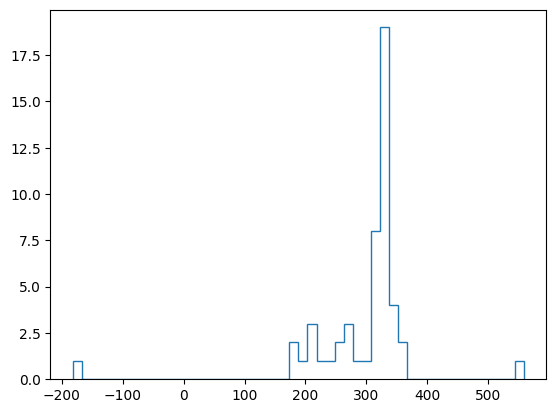

In [30]:
plt.hist(weights_container.weight(), bins=50, histtype="step")
plt.show()

or a some partial weight(s) using the `partial_weight()` method

In [25]:
weights_container.partial_weight(include=["pileup", "l1prefiring"])

array([1.1792506 , 1.10794847, 0.8692264 , 1.06383813, 1.10776369,
       0.82560876, 1.10794847, 0.71529626, 0.69073923, 1.11336179,
       1.05959229, 1.05959229, 1.07586275, 1.09341974, 1.09341974,
       0.91363198, 0.99307543, 1.10627983, 1.02158091, 1.11336179,
       1.05959229, 0.95621222, 1.07586275, 1.11336179, 0.69073923,
       0.82560876, 1.07586275, 1.06383813, 0.58192506, 1.09472015,
       1.04339691, 1.06383813, 1.02158091, 0.59940017, 1.06122857,
       1.0741461 , 0.74581173, 0.78344833, 1.10794847, 0.8692264 ,
       0.63062431, 1.02158091, 1.84323425, 1.07586275, 1.07967284,
       1.09341974, 1.1792506 , 1.11336179, 0.58779121, 1.07586275])

And the total event weight with a given variation is also available

In [26]:
# variations included in the weigths container
weights_container.variations

{'pileupDown', 'pileupUp'}

In [27]:
# weights for the 'pileupUp' shift 
weights_container.weight('pileupUp')

array([ 274.1651138 ,  318.70178408,  307.86411487,  265.27280353,
        303.0743661 ,  300.65590423,  318.70178408,  280.94774594,
        278.9096118 ,  312.837221  ,  320.7689699 ,  320.7689699 ,
        320.56559777,  320.62976383,  320.62976383,  314.18583424,
        321.81663817,  266.95058529,  322.35557276,  312.837221  ,
        320.7689699 ,  319.05969414,  320.56559777,  312.837221  ,
        278.9096118 ,  300.65590423,  320.56559777,  265.27280353,
        366.02936096,  290.08717396,  321.81851525,  265.27280353,
        322.35557276, -298.60772853,  261.66751411,  262.78627765,
        285.66324647,  292.77233393,  318.70178408,  307.86411487,
        284.59341436,  322.35557276,  444.04191896,  320.56559777,
        276.07963996,  320.62976383,  274.1651138 ,  312.837221  ,
        309.35880082,  320.56559777])

We can access to a statistical summary of the weights using the `weightStatistics` attribute

In [28]:
weights_container.weightStatistics

{'genweight': WeightStatistics(sumw=14561.185546875, sumw2=4601303.5, minw=-303.3580017089844, maxw=303.3580017089844, n=50),
 'pileup': WeightStatistics(sumw=49.91920853301455, sumw2=51.958598300576895, minw=0.5819250639914461, maxw=1.8432342460015436, n=50)}

### **Heavy-flavour tagging**

Heavy-flavour jet identification exploits the properties of the hadrons originated in the jet to discriminate heavy flavour (b or c) initiated jets from those arising from light partons. 

b-jet tagging rely on b-hadron properties:
* Long B hadron lifetimes of ~1.5 ps → decay length of ~0.5 mm up to few mm in CMS detector leading to a distinct secondary vertex (SV) different from the primary vertex (PV) of the pp collision event

* Displaced tracks inside b and c jets compared to PV (due to hadron decay happening outside PV) → measured by impact parameter (IP)

* Bottom and charm quarks more massive compared to 1st generation quarks (4.2 and 1.3 GeV respectively) → B and D hadron decay products with higher transverse momenta, resulting in wider jet cones and higher number of jet constituents.



<div>
<img src="https://i.imgur.com/l0s4MHK.png" width="500"/>
</div>


B-tagging is an essential tool to be exploited to study physics processes with b-jets in their final state

<div>
<img src="https://i.imgur.com/9niWWrh.jpg" width="500"/>
</div>

A variety of b-tagging algorithms has been developed by ATLAS and CMS. 

We will use the *DeepJet* tagger (https://arxiv.org/abs/2008.10519). As in the case of muon identification and isolation, we can use the tagger in certain working points

<div>
<img src="https://i.imgur.com/2YAsGjA.png" width="500"/>
</div>

We can access the DeepJet discriminator using the `btagDeepFlavB` field in the Jet collection

In [31]:
# select bjets using DeepJet's tight working point
good_bjets = (
    (events.Jet.pt > 20)
    & (np.abs(events.Jet.eta) < 2.5)
    & (events.Jet.jetId == 6)              # Tight + lepton veto ID working point
    & (events.Jet.btagDeepFlavB > 0.6377)  # DeepJet Tight working point
)

bjets = events.Jet[good_bjets]

#### **b-tagging scale factors**

Since the b-tagging efficiencies measured in data are somewhat different than those predicted by the simulation, scale factors need to be applied to simulated events to take this difference into account.


**b-tagging efficiency**

Since most methods require the knowledge of the MC b-tagging efficiencies, which depend on the event kinematics, it is important to emphasize that CMS only provides the scale factors and it is the analyst responsibility to compute the MC b-tagging efficiencies for each jet flavor in their signal and background MC samples before applying the scale factors. 

The MC b-tagging efficiency $\varepsilon=\varepsilon(p_T, \eta, \text{flav})$ is measured in the same phase space of the analysis but ommiting any related b-tagging selection such as the number of bjets. 

In [32]:
#fname = "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/TTToSemiLeptonic_TuneCP5CR2_13TeV-powheg-pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v1/40000/E7716C5C-E1FA-3C44-BE31-2165BB4C5D72.root"
fname = "TTToSemiLeptonic_20UL16.root"
events = NanoEventsFactory.from_root(
    file={fname: "Events"},
    schemaclass=NanoAODSchema,
).events()

# select jets
phasespace_cuts = (
    (events.Jet.pt > 20) & (np.abs(events.Jet.eta) < 2.5) & (events.Jet.jetId == 6)
)
jets = events.Jet[phasespace_cuts]

# set a variable for the jets passing the b-tagging working point
passbtag = jets.btagDeepFlavB > 0.6377

# initialize efficiency histogram
eff_hist = hist.Hist(
    hist.axis.Variable([20, 30, 50, 70, 100, 140, 200, 300, 600, 1000], name="pt"),
    hist.axis.Regular(4, 0, 2.5, name="abseta"),
    hist.axis.IntCategory([0, 4, 5], name="flavor"),
    hist.axis.Regular(2, 0, 2, name="passWP"),
)
# fill efficiency histogram
eff_hist.fill(
    ak.flatten(jets.pt),
    ak.flatten(abs(jets.eta)),
    ak.flatten(jets.hadronFlavour),
    ak.flatten(passbtag),
)
# compute efficiency
numerator = eff_hist[{"passWP": True}]
denominator = eff_hist[{"passWP": sum}]
efficiency = numerator / denominator
efficiency

/home/juan/Workspace/Base/GFIF/.venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:322: RuntimeWarning: Branch Photon_mass already exists but its values will be replaced with 0.0
  warnings.warn(
/home/juan/Workspace/Base/GFIF/.venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:322: RuntimeWarning: Branch Photon_charge already exists but its values will be replaced with 0.0
  warnings.warn(


Hist(
  Variable([20, 30, 50, 70, 100, 140, 200, 300, 600, 1000], name='pt'),
  Regular(4, 0, 2.5, name='abseta'),
  IntCategory([0, 4, 5], name='flavor'),
  storage=Double()) # Sum: nan (nan with flow)

We need to convert this histogram into a lookup table, that way we'll be able to access the MC b-tagging efficiency as a function of jet flavor, jet $p_T$, and jet $\eta$ later on. 

Coffea provides the **lookup tools**. These tools read a variety of correction file formats and turn them into lookup tables

In [33]:
from coffea.lookup_tools.dense_lookup import dense_lookup

# define an efficiency lookup table
efflookup = dense_lookup(efficiency.values(), [ax.edges for ax in efficiency.axes])
efflookup

<coffea.lookup_tools.dense_lookup.dense_lookup object at 0x7ff3fe898610> 3 dimensional histogram with axes:
	1: [  20.   30.   50.   70.  100.  140.  200.  300.  600. 1000.]
	2: [0.    0.625 1.25  1.875 2.5  ]
	3: [0. 1. 2. 3.]

Notice that hadron flavours (0, 4, 5, 6) turn into (0, 1, 2, 3). Let's modify them to their original values

In [35]:
efflookup._axes[-1] = np.array([0.0, 4.0, 5.0, 6.0])
efflookup

<coffea.lookup_tools.dense_lookup.dense_lookup object at 0x7ff3fe898610> 3 dimensional histogram with axes:
	1: [  20.   30.   50.   70.  100.  140.  200.  300.  600. 1000.]
	2: [0.    0.625 1.25  1.875 2.5  ]
	3: [0. 4. 5. 6.]

In [36]:
# Efficiency at 43 GeV, |eta|=0.2, for light, c, and b quark respectively
efflookup(43, 0.1, np.array([0, 4, 5]))

array([0. , 0. , 0.4])

**b-tagging weights**

b-tagging weights are computed as:

  $$w = \prod_{i=\text{tagged}} SF_{i}  \prod_{j=\text{not tagged}} \frac{1 - SF_{j} \cdot \varepsilon_j}{1-\varepsilon_j} $$
  
  where $\varepsilon_i$ is the MC b-tagging efficiency and $\text{SF}$ are the b-tagging scale factors. $\text{SF}_i$ is a function of the jet flavor, jet $p_T$, and jet $\eta$. It's important to notice that the two products are 1. over jets tagged at the respective working point, and 2. over jets not tagged at the respective working point. **This is not to be confused with the flavor of the jets**.

Let's compute the b-tagging weights for heavy flavour jets

In [37]:
# select heavy flavor jets
phasespace_cuts = (
    (events.Jet.pt > 20) & (np.abs(events.Jet.eta) < 2.5) & (events.Jet.jetId == 6)
)
jets = events.Jet[phasespace_cuts] 
bc_jets = jets[jets.hadronFlavour >= 4]

# heavy flavor jets passing the b-tagging working point
passwp = bc_jets.btagDeepFlavB > 0.6377

# flatten heavy flavor jets
j, nj = ak.flatten(bc_jets), ak.num(bc_jets)

# get b-tagging efficiency
eff = efflookup(bc_jets.pt, np.abs(bc_jets.eta), bc_jets.hadronFlavour)

# get b-tagging scale factors
cset = correctionlib.CorrectionSet.from_file("btagging.json.gz")
flat_sf = cset["deepJet_comb"].evaluate("central", "T", j.hadronFlavour, np.abs(j.eta), j.pt)
sf = ak.unflatten(flat_sf, nj)

# tagged SF = SF * eff / eff = SF
tagged_sf = ak.prod(sf.mask[passwp], axis=-1)

# untagged SF = (1 - SF * eff) / (1 - eff)
ratio = (1 - sf * eff) / (1 - eff)
untagged_sf = ak.prod(ratio.mask[~passwp], axis=-1)

btag_weights = ak.fill_none(tagged_sf * untagged_sf, 1.0)
print(btag_weights)

[1, 0.924, 0.981, 1.09, 0.924, 0.96, ..., 0.909, 0.924, 0.924, 1.07, 0.959]


/home/juan/Workspace/Base/GFIF/.venv/lib/python3.11/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: divide by zero encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


(array([14., 15.,  8.,  6.,  2.,  2.,  0.,  1.,  0.,  2.]),
 array([0.90930156, 0.94441653, 0.97953149, 1.01464645, 1.04976142,
        1.08487638, 1.11999134, 1.15510631, 1.19022127, 1.22533623,
        1.2604512 ]),
 <BarContainer object of 10 artists>)

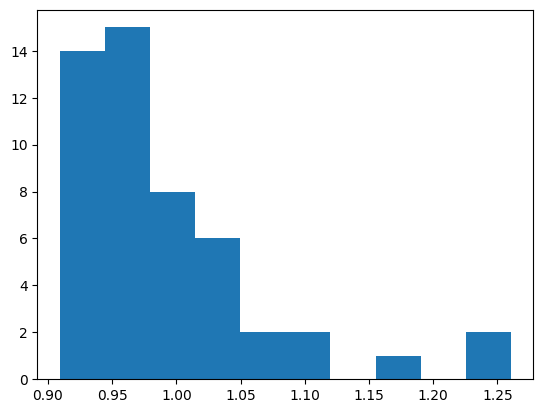

In [41]:
plt.hist(btag_weights)